# Inverter Anomaly Detection Prototype

## Project Overview

This notebook develops a prototype anomaly detection model for solar inverter telemetry using a synthetic predictive maintenance dataset.

The objective is to identify early signs of abnormal inverter behaviour before failure occurs. Anomalies are defined using near-term failure indicators, and model performance is evaluated using ROC-AUC, following Michael’s recommendation.

This prototype focuses on validating the modelling approach, feature pipeline, and evaluation logic. Synthetic data is used to enable development while real operational data is still being collected.

From a business perspective, early detection of abnormal behaviour helps reduce energy loss, prevent unplanned downtime, and support more efficient maintenance decisions.

## Dataset Note

This notebook uses a synthetic inverter predictive maintenance dataset.

The dataset was created to simulate inverter-level telemetry, degradation indicators, environmental conditions, and failure-related signals. Since real data collection is still expected to take additional time, this synthetic dataset allows model development and pipeline validation to begin earlier.

For this prototype, the column `failure_within_7d` is used to define the anomaly label:

- `is_anomaly = 1` means the inverter shows signs associated with failure within the next 7 days.
- `is_anomaly = 0` means no near-term failure signal is present.

This framing allows the anomaly detection system to focus on early warning rather than detecting failure only after it has already happened.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

The dataset contains synthetic daily inverter records, including operating conditions, degradation indicators, maintenance-related variables, and failure labels.

In [3]:
df = pd.read_csv("synthetic_predictive_maintenance_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32627, 42)


,date,inverter_id,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,...,failed_today,is_censored,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
0,2025-01-01,INV-0001,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,...,0,0,97.9300,97.9300,28.510000,28.510000,0.0000,0.0,0.0,0.0
1,2025-01-02,INV-0001,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,...,0,0,97.6950,97.6950,32.575000,32.575000,-0.2350,0.0,0.0,0.0
2,2025-01-03,INV-0001,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,...,0,0,97.8100,97.8100,32.456667,32.456667,0.2300,0.0,0.0,0.0
3,2025-01-04,INV-0001,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,...,0,0,97.7275,97.7275,33.117500,33.117500,-0.2475,0.0,0.0,0.0
4,2025-01-05,INV-0001,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,...,0,0,97.8680,97.8680,33.792000,33.792000,0.5620,0.0,0.0,0.0


## 3. Initial Dataset Review

Before modelling, the dataset is reviewed to understand the available columns, missing values, and overall structure.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32627 entries, 0 to 32626
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              32627 non-null  object 
 1   inverter_id                       32627 non-null  object 
 2   manufacturer                      32627 non-null  object 
 3   climate_zone                      32627 non-null  object 
 4   rated_capacity_kw                 32627 non-null  int64  
 5   installation_quality_score        32627 non-null  float64
 6   maintenance_quality_score         32627 non-null  float64
 7   age_months                        32627 non-null  float64
 8   ambient_temperature_c             32627 non-null  float64
 9   humidity_pct                      32627 non-null  float64
 10  dust_soiling_index                32627 non-null  float64
 11  uv_exposure_index                 32627 non-null  float64
 12  cumu

In [5]:
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
rated_capacity_kw,32627.0,118.523769,69.349305,50.000,75.0000,100.000,150.0000,250.000
installation_quality_score,32627.0,0.877553,0.070556,0.760,0.8160,0.879,0.9410,1.000
maintenance_quality_score,32627.0,0.855399,0.083844,0.706,0.7790,0.859,0.9290,0.999
age_months,32627.0,72.085643,30.464418,12.000,46.8000,71.900,95.9300,131.130
ambient_temperature_c,32627.0,25.010567,5.297533,1.670,21.4500,25.000,28.5800,45.050
humidity_pct,32627.0,56.805569,17.285942,10.000,43.7700,56.590,69.7700,100.000
dust_soiling_index,32627.0,0.428357,0.178572,0.000,0.2990,0.402,0.5445,1.000
uv_exposure_index,32627.0,6.190726,1.392645,1.000,5.2500,6.190,7.1300,10.000
cumulative_uv_exposure,32627.0,960.579651,622.355705,3.230,424.7900,888.310,1441.8300,2342.420
operating_hours_today,32627.0,11.506681,1.205308,6.490,10.7000,11.510,12.3300,15.000


## 4. Create Anomaly Label

For this prototype, anomaly detection is framed as an early warning problem.

Instead of waiting for `failed_today = 1`, the model uses `failure_within_7d` to identify records that show near-term failure risk.

This creates the target variable:

- `is_anomaly = 1`: failure expected within 7 days
- `is_anomaly = 0`: no failure expected within 7 days

This is more useful for maintenance planning because it gives the team time to act before the inverter fails.

In [6]:
df["is_anomaly"] = df["failure_within_7d"].astype(int)

df["is_anomaly"].value_counts()

is_anomaly
0    32044
1      583
Name: count, dtype: int64

In [7]:
anomaly_rate = df["is_anomaly"].mean() * 100

print(f"Anomaly rate: {anomaly_rate:.2f}%")

Anomaly rate: 1.79%


## 5. Check Class Balance

Anomaly detection problems are usually imbalanced because abnormal events are much rarer than normal operating records.

This makes ROC-AUC a useful evaluation metric because it measures how well the model ranks risky records above normal records.

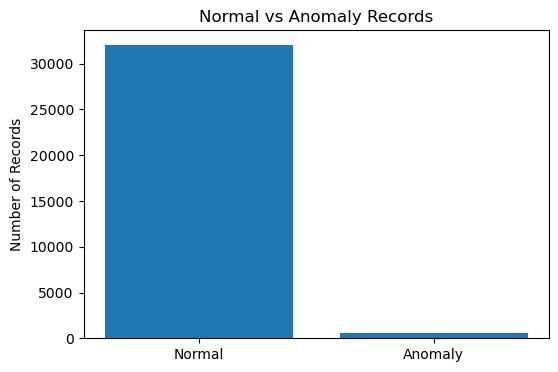

In [9]:
class_counts = df["is_anomaly"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Normal", "Anomaly"], class_counts.values)
plt.title("Normal vs Anomaly Records")
plt.ylabel("Number of Records")
plt.show()

## 6. Feature Selection

The model should only use features that would realistically be available before the failure outcome is known.

Failure labels and future-looking columns are excluded to avoid data leakage.

Selected features include inverter condition, degradation, environment, and operational stress indicators.

In [10]:
exclude_cols = [
    "date",
    "inverter_id",
    "failure_within_7d",
    "failure_within_30d",
    "failure_within_90d",
    "rul_days",
    "failed_today",
    "is_censored",
    "is_anomaly"
]

feature_cols = [col for col in df.columns if col not in exclude_cols]

feature_cols

['manufacturer',
 'climate_zone',
 'rated_capacity_kw',
 'installation_quality_score',
 'maintenance_quality_score',
 'age_months',
 'ambient_temperature_c',
 'humidity_pct',
 'dust_soiling_index',
 'uv_exposure_index',
 'cumulative_uv_exposure',
 'operating_hours_today',
 'cumulative_operating_hours',
 'cumulative_energy_throughput_mwh',
 'efficiency_pct',
 'reactive_power_capability',
 'internal_temperature_c',
 'voltage_ripple',
 'current_harmonic_distortion_pct',
 'insulation_resistance_mohm',
 'capacitor_degradation_indicator',
 'fan_speed_rpm',
 'restart_count_today',
 'error_code_count_today',
 'thermal_cycling_count_today',
 'overload_events_today',
 'efficiency_7d_mean',
 'efficiency_30d_mean',
 'temperature_7d_mean',
 'temperature_30d_mean',
 'efficiency_decline_7d',
 'temp_stress_index',
 'restart_7d_sum',
 'errors_7d_sum']

In [11]:
X = df[feature_cols].copy()
y = df["is_anomaly"].copy()

X.head()

,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,dust_soiling_index,uv_exposure_index,...,thermal_cycling_count_today,overload_events_today,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
0,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,0.292,6.43,...,3,0,97.9300,97.9300,28.510000,28.510000,0.0000,0.0,0.0,0.0
1,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,0.346,6.33,...,0,0,97.6950,97.6950,32.575000,32.575000,-0.2350,0.0,0.0,0.0
2,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,0.329,7.88,...,0,0,97.8100,97.8100,32.456667,32.456667,0.2300,0.0,0.0,0.0
3,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,0.186,7.09,...,4,1,97.7275,97.7275,33.117500,33.117500,-0.2475,0.0,0.0,0.0
4,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,0.368,6.04,...,0,0,97.8680,97.8680,33.792000,33.792000,0.5620,0.0,0.0,0.0


## 7. Encode Categorical Features

The dataset contains categorical fields such as manufacturer and climate zone.

These are converted into numeric dummy variables so they can be used by machine learning models.

In [12]:
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (32627, 38)


,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,dust_soiling_index,uv_exposure_index,cumulative_uv_exposure,operating_hours_today,...,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum,manufacturer_Huawei,manufacturer_SMA,manufacturer_SolarEdge,climate_zone_Hot-Dry,climate_zone_Humid-Subtropical,climate_zone_Temperate
0,100,0.789,0.88,83.00,19.57,40.05,0.292,6.43,6.43,11.78,...,0.0000,0.0,0.0,0.0,False,False,False,False,False,True
1,100,0.789,0.88,83.03,23.48,41.48,0.346,6.33,12.76,12.30,...,-0.2350,0.0,0.0,0.0,False,False,False,False,False,True
2,100,0.789,0.88,83.07,21.69,45.80,0.329,7.88,20.64,12.34,...,0.2300,0.0,0.0,0.0,False,False,False,False,False,True
3,100,0.789,0.88,83.10,21.43,22.49,0.186,7.09,27.74,10.41,...,-0.2475,0.0,0.0,0.0,False,False,False,False,False,True
4,100,0.789,0.88,83.13,23.25,33.41,0.368,6.04,33.78,14.66,...,0.5620,0.0,0.0,0.0,False,False,False,False,False,True


## 8. Temporal Train-Test Split

Since this dataset is time-based, a temporal split is used instead of a random or stratified split.

This ensures that the model is trained on past data and evaluated on future data, which better reflects real-world deployment. Using a random split would introduce data leakage by mixing past and future observations.

The dataset is sorted by date, and the first 80% is used for training while the remaining 20% is used for testing.

In [13]:
# Ensure proper datetime format
df["date"] = pd.to_datetime(df["date"])

# Sort by time
df = df.sort_values("date")

# Split index
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (26101, 43)
Test size: (6526, 43)


In [14]:
# Recreate X and y for split datasets

X_train = train_df[feature_cols]
y_train = train_df["is_anomaly"]

X_test = test_df[feature_cols]
y_test = test_df["is_anomaly"]

# Apply same encoding as before
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns (important!)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Train features:", X_train.shape)
print("Test features:", X_test.shape)

Train features: (26101, 38)
Test features: (6526, 38)


## 9. Isolation Forest Model

Isolation Forest is used as the primary anomaly detection model.

It works by isolating observations that differ significantly from the majority of the data. Unlike supervised models, it does not require labelled data during training and instead learns patterns of normal behaviour.

This makes it well-suited for anomaly detection problems where abnormal cases are rare.

In [15]:
# Build pipeline
iso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    ))
])

# Train model
iso_model.fit(X_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,max_samples,'auto'
,contamination,0.05
,max_features,1.0


## 10. Generate Anomaly Scores

The Isolation Forest model outputs anomaly scores rather than direct classifications.

Higher anomaly scores indicate a higher likelihood of abnormal behaviour. These scores are used for ranking and evaluation using ROC-AUC.

In [16]:
# Get anomaly scores (higher = more normal, so we invert)
train_scores = -iso_model.decision_function(X_train)
test_scores = -iso_model.decision_function(X_test)

# Convert to arrays
train_scores = np.array(train_scores)
test_scores = np.array(test_scores)

## 11. Model Evaluation (ROC-AUC)

Following feedback, ROC-AUC is used as the primary evaluation metric.

ROC-AUC measures how well the model ranks anomalous records above normal records across all classification thresholds. It is particularly useful for imbalanced datasets where accuracy can be misleading.

An AUC score closer to 1 indicates strong separation between normal and anomalous observations.

In [17]:
# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, test_scores)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9799


## 12. ROC Curve

The ROC curve visualises the trade-off between true positive rate (recall) and false positive rate at different thresholds.

A model with strong performance will show a curve that rises quickly toward the top-left corner.

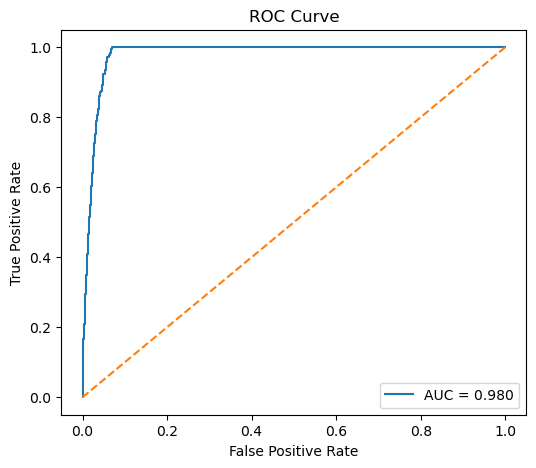

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 13. Threshold-Based Classification

Although anomaly detection is primarily score-based, a threshold can be applied to convert anomaly scores into binary predictions.

This allows evaluation using precision, recall, and F1 score, which are useful for understanding operational trade-offs.

In [20]:
# Choose threshold (can tune later)
threshold = np.percentile(train_scores, 95)

y_pred = (test_scores >= threshold).astype(int)

In [21]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Precision: 0.2608695652173913
Recall: 1.0
F1 Score: 0.41379310344827586

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      6340
           1       0.26      1.00      0.41       186

    accuracy                           0.92      6526
   macro avg       0.63      0.96      0.69      6526
weighted avg       0.98      0.92      0.94      6526



## 14. Confusion Matrix

The confusion matrix shows how many anomalies were correctly detected versus missed, along with false alarms.

This helps assess the operational impact of the model.

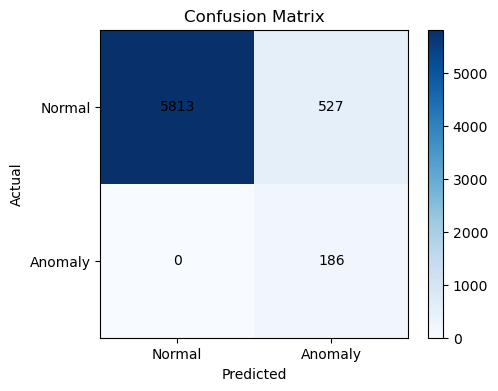

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 15. Supervised Benchmark Model

To compare the unsupervised anomaly detection approach against a supervised baseline, a Random Forest classifier is trained using the same feature set and anomaly label.

This benchmark helps answer a practical question:

Can a supervised model separate near-term failure risk from normal behaviour better than the unsupervised anomaly detection model?

The benchmark is not intended to replace the anomaly detection design. It is included to provide a performance reference point.

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_probs)

print(f"Random Forest ROC-AUC Score: {rf_auc:.4f}")

Random Forest ROC-AUC Score: 0.9982


## 16. Model Comparison

This section compares the Isolation Forest anomaly score against the supervised Random Forest benchmark using ROC-AUC.

ROC-AUC is used because it evaluates how well each model ranks high-risk inverter records above normal records across thresholds.

In [24]:
comparison_df = pd.DataFrame({
    "Model": ["Isolation Forest", "Random Forest Benchmark"],
    "ROC_AUC": [auc_score, rf_auc]
})

comparison_df

,Model,ROC_AUC
0,Isolation Forest,0.979904
1,Random Forest Benchmark,0.998206


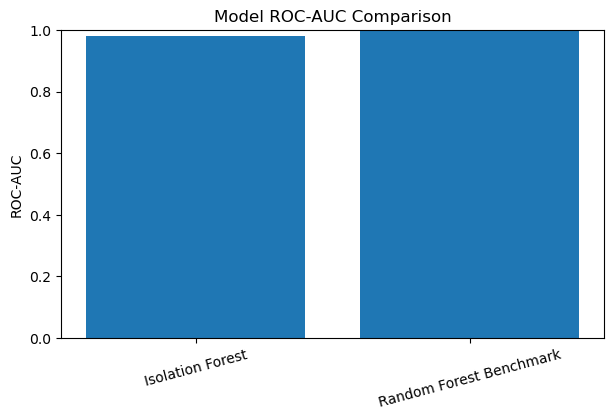

In [25]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["Model"], comparison_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC Comparison")
plt.xticks(rotation=15)
plt.show()

## 17. Feature Importance

The supervised benchmark model also provides feature importance values.

These are useful for understanding which inverter conditions and degradation indicators are most strongly associated with near-term anomaly risk.

In [26]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
25,efficiency_30d_mean,0.189831
24,efficiency_7d_mean,0.183064
12,efficiency_pct,0.130337
31,errors_7d_sum,0.106347
18,capacitor_degradation_indicator,0.093681
30,restart_7d_sum,0.072528
27,temperature_30d_mean,0.055047
13,reactive_power_capability,0.049442
26,temperature_7d_mean,0.042790
21,error_code_count_today,0.019549


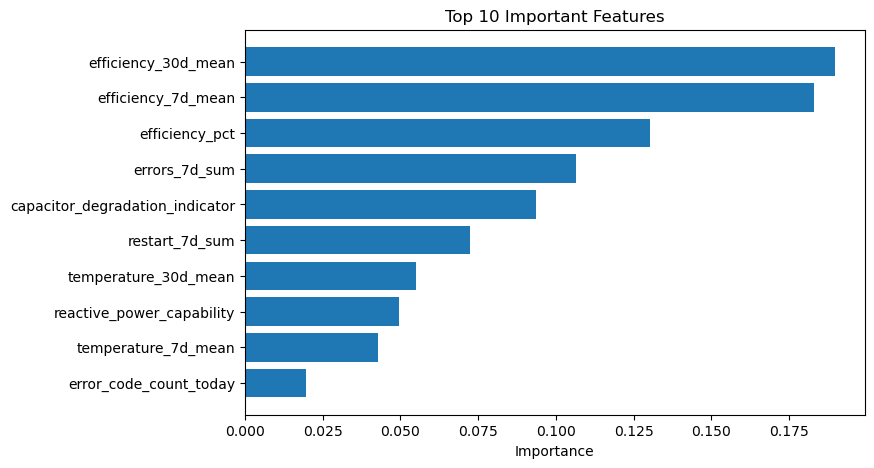

In [27]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

## 18. Feature Interpretation

The most important features provide insight into the types of signals associated with abnormal inverter behaviour.

In this prototype, the strongest indicators are expected to relate to:

- efficiency degradation
- internal temperature behaviour
- capacitor degradation
- voltage ripple
- current harmonic distortion
- restart frequency
- error code frequency
- thermal cycling

These features are operationally meaningful because inverter faults often appear as changes in efficiency, heat, electrical stability, and repeated fault events before full failure occurs.

In [30]:
# For now, we use Random Forest feature importance as the interpretability layer rather than SHAP

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
25,efficiency_30d_mean,0.189831
24,efficiency_7d_mean,0.183064
12,efficiency_pct,0.130337
31,errors_7d_sum,0.106347
18,capacitor_degradation_indicator,0.093681
30,restart_7d_sum,0.072528
27,temperature_30d_mean,0.055047
13,reactive_power_capability,0.049442
26,temperature_7d_mean,0.042790
21,error_code_count_today,0.019549


## Model Interpretability

For this prototype, feature importance from the supervised benchmark model is used as the initial interpretability layer.

This helps identify which inverter conditions are most associated with near-term anomaly risk. In a later production version, SHAP can be added for record-level explanations once the final model type and environment are confirmed.

## 20. Prototype Results Summary

This section summarises the key prototype results in a format suitable for progress reporting.

In [31]:
summary = {
    "Dataset Rows": df.shape[0],
    "Dataset Features Used": X_train.shape[1],
    "Anomaly Definition": "failure_within_7d",
    "Anomaly Rate (%)": round(df["is_anomaly"].mean() * 100, 2),
    "Isolation Forest ROC-AUC": round(auc_score, 4),
    "Random Forest Benchmark ROC-AUC": round(rf_auc, 4),
    "Threshold Used": round(threshold, 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1 Score": round(f1_score(y_test, y_pred), 4)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Dataset Rows,32627
1,Dataset Features Used,38
2,Anomaly Definition,failure_within_7d
3,Anomaly Rate (%),1.79
4,Isolation Forest ROC-AUC,0.9799
5,Random Forest Benchmark ROC-AUC,0.9982
6,Threshold Used,0.0
7,Precision,0.2609
8,Recall,1.0
9,F1 Score,0.4138


## 21. Conclusion

This prototype demonstrates an initial anomaly detection workflow for inverter telemetry using a synthetic predictive maintenance dataset.

The dataset was adapted into an anomaly detection problem by using `failure_within_7d` as the early-warning anomaly label. A temporal train-test split was used to avoid data leakage, ensuring that the model was trained on earlier records and evaluated on later records.

The Isolation Forest model was used as the primary anomaly detection approach, while a supervised Random Forest benchmark was included for comparison. Model performance was evaluated using ROC-AUC, following Michael’s recommendation, because ROC-AUC is more appropriate than accuracy for imbalanced anomaly detection problems.

The prototype also includes threshold-based precision, recall, and F1 score to understand operational trade-offs. Feature importance from the supervised benchmark provides an initial explanation of which inverter conditions are associated with near-term anomaly risk.

Overall, this notebook validates the core modelling workflow and provides a foundation for further development using real operational inverter data once available.

## 22. Next Steps

Recommended next steps:

1. Tune the anomaly threshold based on operational preference between false alarms and missed failures.
2. Add ROC-AUC and PR-AUC tracking to the evaluation pipeline.
3. Test XGBoost as the supervised fault classification model.
4. Add SHAP explanations for high-risk inverter records.
5. Validate the workflow on real inverter telemetry once available.
6. Package the pipeline into reusable scripts for repeatable training and evaluation.